# Dev notebook — Cell 10 (error analysis) + Cell 11 (model export for the demo app)

Reads the **output of the `bangla-cyberbullying` notebook** instead of re-running Cells 1–9.
When these cells are final they get appended to the full pipeline for one last end-to-end run.

**Before running**
1. **Add Input → Your Work → Notebooks → `bangla-cyberbullying`** (attaches that run's output files)
2. Settings → **Accelerator: None** — both cells are CPU-only, so no GPU quota is spent
3. Settings → **Internet: On** — Cell 11 installs the BanglaBERT normalizer
4. **Save Version → Save & Run All** (~5 min)

**After:** Output tab → download `cyberbullying_model.zip` (~420 MB) for the app.

In [1]:
# ============================================================
# SETUP — copy the previous run's outputs into the usual layout
# ============================================================
import glob, os, shutil
PROJECT_DIR = '/kaggle/working'
SPLIT_DIR   = f'{PROJECT_DIR}/data/splits'
RESULT_DIR  = f'{PROJECT_DIR}/reports/results'
FIG_DIR     = f'{PROJECT_DIR}/reports/figures'
for p in (SPLIT_DIR, RESULT_DIR, FIG_DIR):
    os.makedirs(p, exist_ok=True)

NEEDED = {SPLIT_DIR:  ['train.csv', 'val.csv', 'test.csv', 'label_map.json'],
          RESULT_DIR: ['model_disagreements.csv']}
for dest, names in NEEDED.items():
    for name in names:
        hits = [h for h in glob.glob(f'/kaggle/input/**/{name}', recursive=True)]
        assert len(hits) == 1, f'{name}: expected 1 match, found {hits} — is the notebook output attached?'
        shutil.copy(hits[0], f'{dest}/{name}')
print('copied:', {os.path.basename(d): n for d, n in NEEDED.items()})

# fine-tuned models saved by Cells 6 and 7 of the pipeline run
BERT_DIR   = [os.path.dirname(p) for p in glob.glob('/kaggle/input/**/models/banglabert/config.json', recursive=True)]
TFIDF_PATH = glob.glob('/kaggle/input/**/models/tfidf_logreg.joblib', recursive=True)
assert len(BERT_DIR) == 1 and len(TFIDF_PATH) == 1, f'model files not found: {BERT_DIR} {TFIDF_PATH}'
BERT_DIR, TFIDF_PATH = BERT_DIR[0], TFIDF_PATH[0]
print('models:', BERT_DIR, '|', TFIDF_PATH)

copied: {'splits': ['train.csv', 'val.csv', 'test.csv', 'label_map.json'], 'results': ['model_disagreements.csv']}
models: /kaggle/input/notebooks/shishirsys/bangla-cyberbullying/models/banglabert | /kaggle/input/notebooks/shishirsys/bangla-cyberbullying/models/tfidf_logreg.joblib


test comments: 6,197

TOP CONFUSIONS  (true -> predicted)

TF-IDF  (1,054 errors)
  Harassment         -> Neutral             190  (18.0% of errors)
  Neutral            -> Harassment          182  (17.3% of errors)
  Sexual Aggression  -> Harassment          101  ( 9.6% of errors)
  Harassment         -> Sexual Aggression    97  ( 9.2% of errors)
  Sexual Aggression  -> Neutral              79  ( 7.5% of errors)
  Neutral            -> Sexual Aggression    58  ( 5.5% of errors)

BanglaBERT  (972 errors)
  Neutral            -> Harassment          206  (21.2% of errors)
  Harassment         -> Neutral             124  (12.8% of errors)
  Harassment         -> Sexual Aggression   123  (12.7% of errors)
  Sexual Aggression  -> Harassment          108  (11.1% of errors)
  Sexual Aggression  -> Neutral              73  ( 7.5% of errors)
  Neutral            -> Sexual Aggression    71  ( 7.3% of errors)

BOTH MODELS WRONG
  both wrong                      : 627  (10.1% of test)
  ...and agr

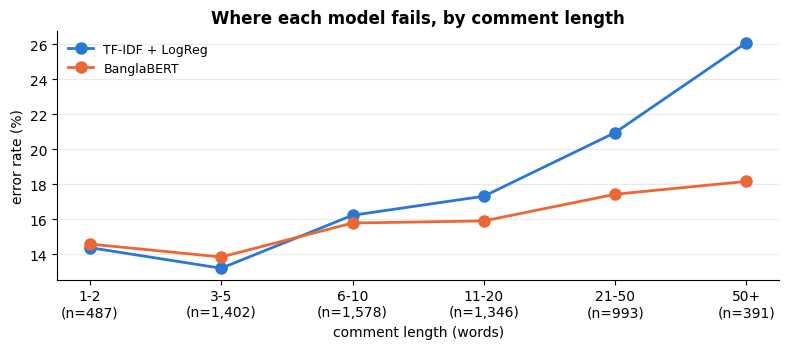


ERROR RATE BY PHENOMENON
                                        n  tfidf_err  bert_err  bert_gain
phenomenon                                                               
ALL test comments                    6197      0.170     0.157      0.013
code-mixed (>=30% Latin chars)         54      0.204     0.204      0.000
contains emoji                        167      0.066     0.084     -0.018
very short (<=2 words)                487      0.144     0.146     -0.002
question mark (rhetorical/sarcasm?)   695      0.239     0.200      0.039
informal pronoun তুই/তোর/তোকে/তোদের   753      0.147     0.122      0.025
near-twin in train (sim>=0.80)        477      0.055     0.046      0.008

WINS BY CLASS  (only one model correct)
outcome            only_bert  only_tfidf  both_wrong  net_bert
Label                                                         
Neutral                  106         143         185       -37
Harassment               141          90         217        51
Sexual Aggressi

In [2]:
# ============================================================
# CELL 10 — Error Analysis  (context.md Objective 4)  — CPU only
# Where and why do the models fail? Reads only saved prediction
# files (copied in by the setup cell above), so it needs no GPU.
# ============================================================
import re, json, numpy as np, pandas as pd, matplotlib.pyplot as plt

PROJECT_DIR = '/kaggle/working'
RESULT_DIR  = f'{PROJECT_DIR}/reports/results'
FIG_DIR     = f'{PROJECT_DIR}/reports/figures'
LABELS = ['Neutral', 'Harassment', 'Sexual Aggression', 'Hate Speech', 'Violent Extremism']

d = pd.read_csv(f'{RESULT_DIR}/model_disagreements.csv')
d['Text']  = d['Text'].astype(str)
d['tf_ok'] = d['tfidf_pred'] == d['Label']
d['bb_ok'] = d['bert_pred']  == d['Label']
wc = d['Text'].str.split().str.len()
print(f'test comments: {len(d):,}')

# ------------------------------------------------------------
# 1. Which classes get confused with which?
# ------------------------------------------------------------
print('\n' + '=' * 60); print('TOP CONFUSIONS  (true -> predicted)')
for name, col, ok in [('TF-IDF', 'tfidf_pred', 'tf_ok'), ('BanglaBERT', 'bert_pred', 'bb_ok')]:
    top = d[~d[ok]].groupby(['Label', col]).size().sort_values(ascending=False).head(6)
    print(f'\n{name}  ({(~d[ok]).sum():,} errors)')
    for (t, p), c in top.items():
        print(f'  {t:18s} -> {p:18s} {c:4d}  ({c/(~d[ok]).sum()*100:4.1f}% of errors)')

# ------------------------------------------------------------
# 2. Both models wrong — and wrong in the SAME way?
#    Two very different models agreeing on the same "wrong" label is
#    the classic signature of an annotation error, not a model error.
# ------------------------------------------------------------
bw    = d[d['outcome'] == 'both_wrong']
agree = bw[bw['tfidf_pred'] == bw['bert_pred']]
print('\n' + '=' * 60); print('BOTH MODELS WRONG')
print(f'  both wrong                      : {len(bw):,}  ({len(bw)/len(d)*100:.1f}% of test)')
print(f'  ...and agree on the same label  : {len(agree):,}  ({len(agree)/max(len(bw),1)*100:.1f}% of both-wrong)'
      f'  <- candidate annotation errors')
print('\n  gold label (rows) vs the label both models chose (cols):')
print(pd.crosstab(agree['Label'], agree['bert_pred']).reindex(index=LABELS, columns=LABELS, fill_value=0)
      .to_string())
print('\n  examples (gold -> both models said):')
for _, r in agree.sample(min(8, len(agree)), random_state=42).iterrows():
    print(f'   [{r["Label"]} -> {r["bert_pred"]}]  {r["Text"][:90]}')

# ------------------------------------------------------------
# 3. Error rate by comment length
# ------------------------------------------------------------
buckets = ['1-2', '3-5', '6-10', '11-20', '21-50', '50+']
d['len_bucket'] = pd.cut(wc, [0, 2, 5, 10, 20, 50, 10_000], labels=buckets)
by_len = d.groupby('len_bucket', observed=True).agg(
    n=('Text', 'size'),
    tfidf_err=('tf_ok', lambda s: 1 - s.mean()),
    bert_err=('bb_ok',  lambda s: 1 - s.mean()))
by_len['bert_gain'] = by_len['tfidf_err'] - by_len['bert_err']
print('\n' + '=' * 60); print('ERROR RATE BY LENGTH (words)')
print(by_len.round(3).to_string())

C_TF, C_BB, INK2 = '#2a78d6', '#eb6834', '#52514e'
fig, ax = plt.subplots(figsize=(8, 3.6))
x = range(len(by_len))
ax.plot(x, by_len['tfidf_err'] * 100, marker='o', ms=8, lw=2, color=C_TF, label='TF-IDF + LogReg')
ax.plot(x, by_len['bert_err']  * 100, marker='o', ms=8, lw=2, color=C_BB, label='BanglaBERT')
ax.set_xticks(list(x)); ax.set_xticklabels([f'{b}\n(n={n:,})' for b, n in zip(by_len.index, by_len['n'])])
ax.set_xlabel('comment length (words)'); ax.set_ylabel('error rate (%)')
ax.set_title('Where each model fails, by comment length', fontweight='bold')
ax.yaxis.grid(True, color='#eceae5'); ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/10_error_by_length.png', bbox_inches='tight'); plt.show()

# ------------------------------------------------------------
# 4. Difficult Bangla social-media phenomena
# ------------------------------------------------------------
EMOJI_RE = r'[\U0001F300-\U0001FAFF☀-➿]'
latin_share = d['Text'].map(lambda s: len(re.findall(r'[A-Za-z]', s)) / max(len(re.sub(r'\s', '', s)), 1))
flags = {
    'ALL test comments':                  pd.Series(True, index=d.index),
    'code-mixed (>=30% Latin chars)':     latin_share >= 0.30,
    'contains emoji':                     d['Text'].str.contains(EMOJI_RE, regex=True),
    'very short (<=2 words)':             wc <= 2,
    'question mark (rhetorical/sarcasm?)': d['Text'].str.contains(r'\?', regex=True),
    'informal pronoun তুই/তোর/তোকে/তোদের':  d['Text'].str.contains('তুই|তোর|তোকে|তোদের', regex=True),
    'near-twin in train (sim>=0.80)':      d['near_twin_in_train'].astype(bool),
}
rows = [{'phenomenon': k, 'n': int(m.sum()),
         'tfidf_err': 1 - d.loc[m, 'tf_ok'].mean(),
         'bert_err':  1 - d.loc[m, 'bb_ok'].mean()} for k, m in flags.items() if m.sum()]
phen = pd.DataFrame(rows).set_index('phenomenon')
phen['bert_gain'] = phen['tfidf_err'] - phen['bert_err']
print('\n' + '=' * 60); print('ERROR RATE BY PHENOMENON')
print(phen.round(3).to_string())

# ------------------------------------------------------------
# 5. Where does each model win?
# ------------------------------------------------------------
wins = pd.crosstab(d['Label'], d['outcome']).reindex(LABELS)
wins = wins.reindex(columns=['only_bert', 'only_tfidf', 'both_wrong'], fill_value=0)
wins['net_bert'] = wins['only_bert'] - wins['only_tfidf']
print('\n' + '=' * 60); print('WINS BY CLASS  (only one model correct)')
print(wins.to_string())

# ------------------------------------------------------------
# 6. Sample for MANUAL review (fill `manual_verdict` by hand)
# ------------------------------------------------------------
def take(df, k, group):
    return df.sample(min(k, len(df)), random_state=42).assign(review_group=group)

review = pd.concat([
    take(agree, 50, 'both_wrong_same_label'),
    take(bw[bw['tfidf_pred'] != bw['bert_pred']], 30, 'both_wrong_different_label'),
    take(d[d['outcome'] == 'only_bert'],  30, 'only_bert_correct'),
    take(d[d['outcome'] == 'only_tfidf'], 30, 'only_tfidf_correct'),
])[['review_group', 'Text', 'Label', 'tfidf_pred', 'bert_pred']]
review['manual_verdict'] = ''   # gold_wrong / ambiguous / model_wrong
review.to_csv(f'{RESULT_DIR}/error_review_sample.csv', index=False, encoding='utf-8-sig')

by_len.round(4).to_csv(f'{RESULT_DIR}/error_by_length.csv')
phen.round(4).to_csv(f'{RESULT_DIR}/error_by_phenomenon.csv')
json.dump({'both_wrong': len(bw), 'both_wrong_same_label': len(agree)},
          open(f'{RESULT_DIR}/error_summary.json', 'w'), indent=2)
print(f'\nSaved -> error_review_sample.csv ({len(review)} rows for manual review)')
print('Saved -> error_by_length.csv | error_by_phenomenon.csv | error_summary.json')
print(f'Saved -> {FIG_DIR}/10_error_by_length.png')

In [3]:
# ============================================================
# CELL 11 — Export the fine-tuned models for the demo app + sanity checks
# 1) the app's preprocessing reproduces the training text columns exactly
# 2) the saved BanglaBERT / TF-IDF models reproduce their test predictions
# 3) everything the app needs goes into one zip (Output tab)
# CPU is enough. Needs Settings -> Internet: On (normalizer install).
# ============================================================
!pip install -q git+https://github.com/csebuetnlp/normalizer

import json, os, shutil, platform, joblib, torch, sklearn, transformers
import numpy as np, pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from normalizer import normalize as bn_normalize

# ---- preprocessing: byte-for-byte the same code as app/preprocess.py ----
import re, unicodedata

# --- Cell 2: Unicode NFC, zero-width chars removed, whitespace collapsed ---
def clean_text(s):
    s = unicodedata.normalize('NFC', str(s))
    s = s.replace('\u200b', '').replace('\u200c', '').replace('\u200d', '')
    return re.sub(r'\s+', ' ', s).strip()

# --- Cell 5: the two model-specific views ---
URL_RE   = re.compile(r'https?://\S+|www\.\S+')
PUNCT_RE = re.compile(r'([^\u0980-\u09FFa-zA-Z0-9\s])')
DIGIT_RE = re.compile(r'[0-9\u09E6-\u09EF]+')
URL_TOK, NUM_TOK = ' urltoken ', ' numtoken '

def prep_bert(s):
    s = URL_RE.sub(URL_TOK, str(s))
    return re.sub(r'\s+', ' ', s).strip()

def prep_tfidf(s):
    s = URL_RE.sub(URL_TOK, str(s))
    s = s.replace('\ufe0f', '')
    s = PUNCT_RE.sub(r' \1 ', s)
    s = DIGIT_RE.sub(NUM_TOK, s)
    return re.sub(r'\s+', ' ', s).strip()

label2id = json.load(open(f'{SPLIT_DIR}/label_map.json'))['label2id']
LABELS = [l for l, _ in sorted(label2id.items(), key=lambda kv: kv[1])]
test = pd.read_csv(f'{SPLIT_DIR}/test.csv')
dis  = pd.read_csv(f'{RESULT_DIR}/model_disagreements.csv')
assert (dis['Text'].values == test['Text'].values).all()

# ---- 1. preprocessing parity ----
for col, fn in (('text_bert', prep_bert), ('text_tfidf', prep_tfidf)):
    mism = (test['Text'].map(clean_text).map(fn) != test[col].astype(str))
    print(f'{col:10s}: app preprocessing matches training on {(~mism).sum():,}/{len(test):,} test rows')
    assert mism.sum() == 0, test.loc[mism, ['Text', col]].head()

# ---- 2. saved models reproduce their predictions (CPU vs GPU-fp16 may flip a few borderline rows) ----
tok   = AutoTokenizer.from_pretrained(BERT_DIR)
model = AutoModelForSequenceClassification.from_pretrained(BERT_DIR).eval()
model.config.id2label = {i: l for i, l in enumerate(LABELS)}
model.config.label2id = label2id

@torch.no_grad()
def bert_probs(texts):
    enc = tok([bn_normalize(prep_bert(clean_text(t))) for t in texts], truncation=True,
              max_length=128, padding=True, return_tensors='pt')
    return torch.softmax(model(**enc).logits, -1).numpy()

tfidf  = joblib.load(TFIDF_PATH)
sample = test.sample(300, random_state=42)
pb = np.concatenate([bert_probs(sample['Text'].iloc[i:i+32].tolist()) for i in range(0, 300, 32)])
agree_bert = np.mean(np.array([LABELS[i] for i in pb.argmax(1)]) == dis.loc[sample.index, 'bert_pred'].values)
pt = tfidf['model'].predict(tfidf['vectorizer'].transform(sample['Text'].map(clean_text).map(prep_tfidf)))
agree_tf = np.mean(np.array([LABELS[i] for i in pt]) == dis.loc[sample.index, 'tfidf_pred'].values)
print(f'BanglaBERT (CPU) agrees with saved test predictions: {agree_bert*100:.1f}% of 300')
print(f'TF-IDF           agrees with saved test predictions: {agree_tf*100:.1f}% of 300')
assert agree_bert >= 0.98 and agree_tf == 1.0, 'exported model does not reproduce the reported results'

# ---- 3. demo examples: short, correctly classified by both models, 3 per class ----
ok = dis[(dis['outcome'] == 'both_correct') & (dis['Text'].str.split().str.len().between(3, 20))]
examples = pd.concat([ok[ok['Label'] == l].sample(min(3, int((ok['Label'] == l).sum())), random_state=42)
                      for l in LABELS])[['Text', 'Label']]

# ---- 4. export bundle ----
EXP = '/kaggle/working/cyberbullying_model'
shutil.rmtree(EXP, ignore_errors=True)
model.save_pretrained(f'{EXP}/banglabert'); tok.save_pretrained(f'{EXP}/banglabert')
shutil.copy(TFIDF_PATH, f'{EXP}/tfidf_logreg.joblib')
shutil.copy(f'{SPLIT_DIR}/label_map.json', f'{EXP}/label_map.json')
examples.to_csv(f'{EXP}/examples.csv', index=False, encoding='utf-8')
json.dump({'python': platform.python_version(), 'torch': torch.__version__,
           'transformers': transformers.__version__, 'scikit-learn': sklearn.__version__},
          open(f'{EXP}/versions.json', 'w'), indent=2)
shutil.make_archive('/kaggle/working/cyberbullying_model', 'zip', EXP)
print(f"\ncyberbullying_model.zip  {os.path.getsize('/kaggle/working/cyberbullying_model.zip')/1e6:.0f} MB")
print(json.load(open(f'{EXP}/versions.json')))
print('\ndemo predictions:')
for t, l in zip(examples['Text'].head(5), examples['Label'].head(5)):
    p = bert_probs([t])[0]
    print(f'  [{l:18s}] -> {LABELS[p.argmax()]:18s} ({p.max():.2f})  {t[:60]}')

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
text_bert : app preprocessing matches training on 6,197/6,197 test rows
text_tfidf: app preprocessing matches training on 6,197/6,197 test rows


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BanglaBERT (CPU) agrees with saved test predictions: 100.0% of 300
TF-IDF           agrees with saved test predictions: 100.0% of 300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


cyberbullying_model.zip  414 MB
{'python': '3.12.13', 'torch': '2.10.0+cpu', 'transformers': '5.0.0', 'scikit-learn': '1.6.1'}

demo predictions:
  [Neutral           ] -> Neutral            (0.71)  হাহা দিয়ে আমি Top Fan বেশি করে হাহা রিয়েক্ট দিন
  [Neutral           ] -> Neutral            (0.98)  ধন্যবাদ নিজের ভুল বুঝার জন্য।অাল্লাহ অাপনাকে মাফ করুন।অামিন
  [Neutral           ] -> Neutral            (0.72)  তুমি কে আমাকে পরিচয় দাও তাহলে আমি
  [Harassment        ] -> Harassment         (0.96)  পুরান পাগলে ভাত পাই না... নতুন পাগলের আমদানি...
  [Harassment        ] -> Harassment         (0.95)  ঠেলার নাম বাবাজি কেন কথা বলার আগে কি ভেবে চিন্তে কথা বলতে পা
